In [ ]:
#!pip install seaborn

In [ ]:
#import nibabel as nib
#from nilearn import plotting
#import matplotlib.pyplot as plt
#import nistats

In [134]:
from dipy.io.image import load_nifti
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [86]:
fraw_matlab = Path("C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/data_reference/_FA.nii.gz")
fraw_python = Path("C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/output_python_v1/FA_final.nii.gz")
data_matlab, affine_matlab = load_nifti(fraw_matlab)
data_python, affine_python = load_nifti(fraw_python)

In [87]:
data_matlab = np.nan_to_num(data_matlab)

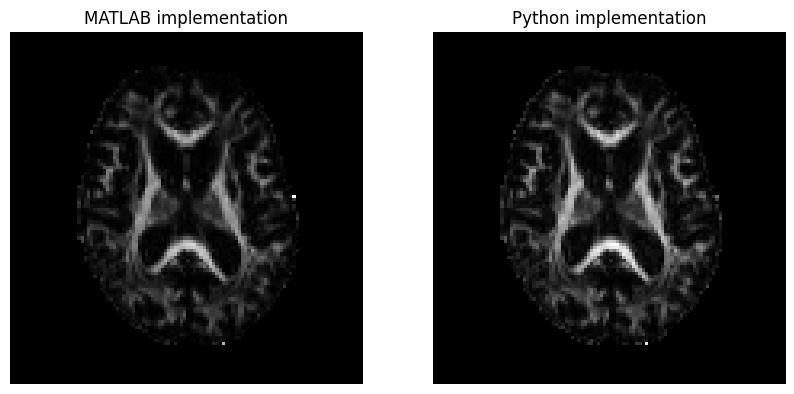

In [93]:
axial_middle_matlab = data_matlab.shape[2] // 2
axial_middle_python = data_python.shape[2] // 2
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1).set_axis_off()
plt.imshow(data_matlab[:, :, axial_middle_matlab].T, cmap="gray", origin="lower")
plt.title('MATLAB implementation')
plt.subplot(1, 2, 2).set_axis_off()
plt.imshow(data_python[:, :, axial_middle_python].T, cmap="gray", origin="lower")
plt.title('Python implementation')
plt.show()

In [167]:
mask_matlab = (data_matlab >= 0.6).astype(bool)

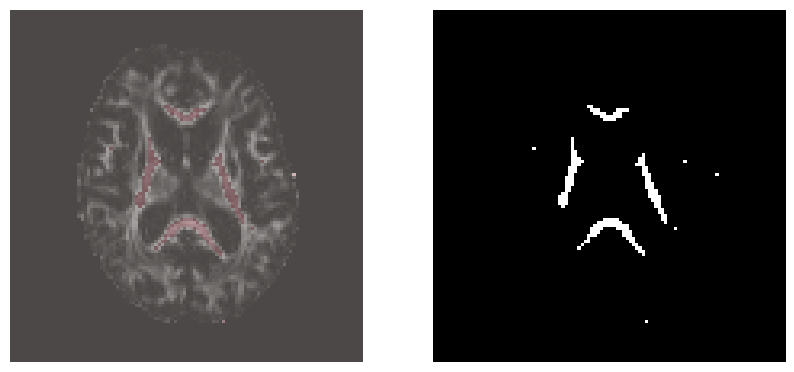

In [168]:
axial_middle_matlab = data_matlab.shape[2] // 2
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1).set_axis_off()
plt.imshow(data_matlab[:, :, axial_middle_matlab].T, cmap="gray", origin="lower")
plt.imshow(mask_matlab[:, :, axial_middle_matlab].T, cmap='Reds', alpha=0.3, origin="lower")
plt.subplot(1, 2, 2).set_axis_off()
plt.imshow(mask_matlab[:, :, axial_middle_matlab].T, cmap="gray", origin="lower")
plt.show()

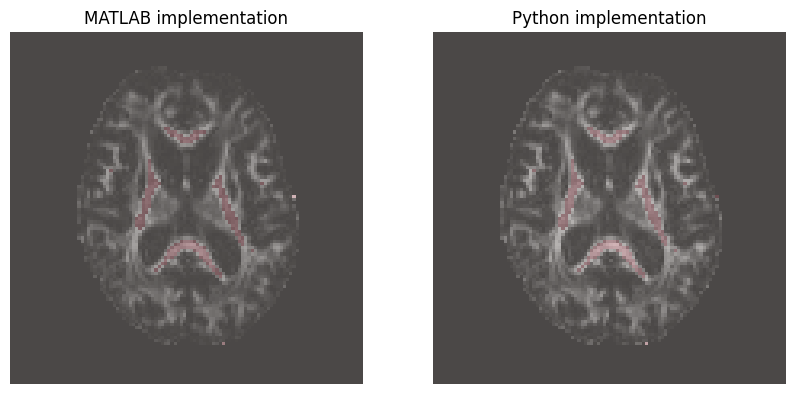

In [169]:
axial_middle_matlab = data_matlab.shape[2] // 2
axial_middle_python = data_python.shape[2] // 2
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1).set_axis_off()
plt.imshow(data_matlab[:, :, axial_middle_matlab].T, cmap="gray", origin="lower")
plt.imshow(mask_matlab[:, :, axial_middle_matlab].T, cmap='Reds', alpha=0.3, origin="lower")
plt.title('MATLAB implementation')
plt.subplot(1, 2, 2).set_axis_off()
plt.imshow(data_python[:, :, axial_middle_python].T, cmap="gray", origin="lower")
plt.imshow(mask_matlab[:, :, axial_middle_matlab].T, cmap='Reds', alpha=0.3, origin="lower")
plt.title('Python implementation')
plt.show()

In [170]:
masked_matlab = data_matlab * mask_matlab

In [171]:
masked_matlab.shape

(110, 110, 60)

In [172]:
masked_python = data_python * mask_matlab

In [173]:
masked_python.shape

(110, 110, 60)

Text(0.5, 1.0, 'Python implementation')

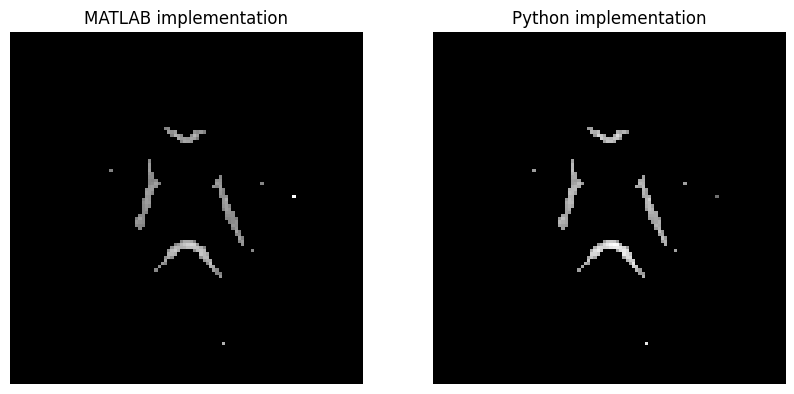

In [174]:
axial_masked_matlab = masked_matlab.shape[2] // 2
axial_masked_python = masked_python.shape[2] // 2
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1).set_axis_off()
plt.imshow(masked_matlab[:, :, axial_masked_matlab].T, cmap="gray", origin="lower")
plt.title('MATLAB implementation')
plt.subplot(1, 2, 2).set_axis_off()
plt.imshow(masked_python[:, :, axial_masked_python].T, cmap="gray", origin="lower")
plt.title('Python implementation')

In [175]:
vector_masked_matlab = data_matlab[mask_matlab]

In [176]:
vector_masked_matlab.shape

(3842,)

In [177]:
vector_masked_python = data_python[mask_matlab]

In [178]:
vector_masked_python.shape

(3842,)

Text(0.5, 0, 'Implementation')

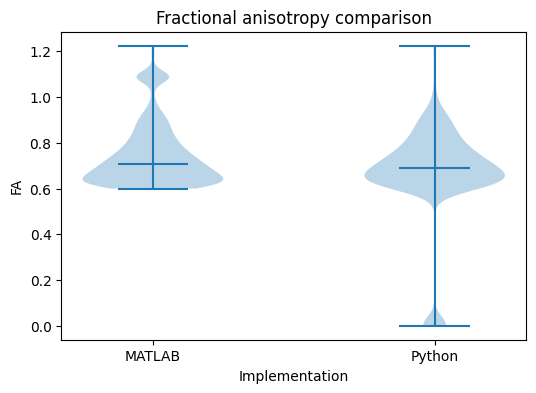

In [179]:
all_data = [vector_masked_matlab, vector_masked_python]

fig, ax = plt.subplots(figsize=(6, 4))
ax.violinplot(all_data, showmedians=True)

ax.set_title('Fractional anisotropy comparison')
ax.set_xticks([1, 2], ['MATLAB', 'Python'])
ax.set_ylabel('FA')
ax.set_xlabel('Implementation')

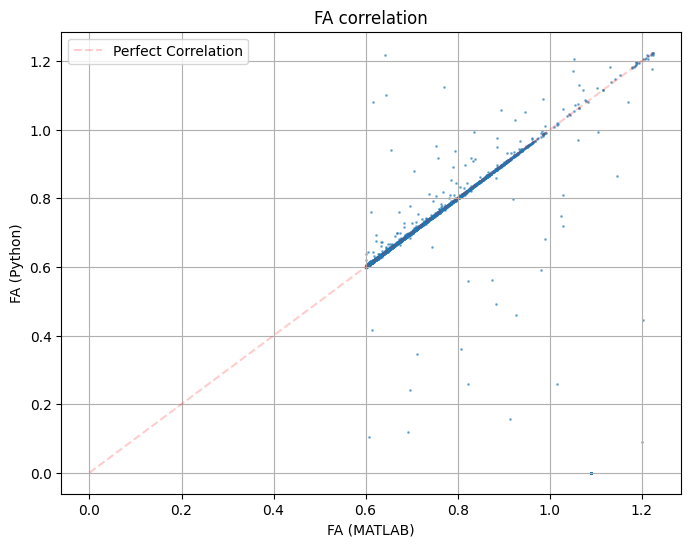

In [180]:
plt.figure(figsize=(8, 6))
plt.scatter(vector_masked_matlab, vector_masked_python, alpha=0.5, s=1)

min_val = min(min(vector_masked_matlab), min(vector_masked_python))
max_val = max(max(vector_masked_matlab), max(vector_masked_python))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Correlation', alpha=0.2)

plt.xlabel('FA (MATLAB)')
plt.ylabel('FA (Python)')
plt.title('FA correlation')
plt.legend()
plt.grid(True)
plt.show()

In [181]:
absolute_error = np.abs(vector_masked_matlab - vector_masked_python)
mean_absolute_error = np.mean(absolute_error)
mean_absolute_error

np.float32(0.07850572)

In [243]:
def plot_violin_scatter(matlab_nii_file, python_nii_file, metric_abbr, WM_mask):
    fraw_matlab = Path(matlab_nii_file)
    fraw_python = Path(python_nii_file)
    data_matlab, affine_matlab = load_nifti(fraw_matlab)
    data_python, affine_python = load_nifti(fraw_python)

    data_matlab = np.nan_to_num(data_matlab)

    if metric_abbr == "Kpar" or metric_abbr == "Kperp" or metric_abbr == "Wmean" or metric_abbr == "Wpowder":
        data_python[data_python >= 4] = 0
        data_python[data_python <= 0] = 0

    axial_middle_matlab = data_matlab.shape[2] // 2
    axial_middle_python = data_python.shape[2] // 2
    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1).set_axis_off()
    plt.imshow(data_matlab[:, :, axial_middle_matlab].T, cmap="gray", origin="lower")
    plt.title(f"{metric_abbr} (MATLAB)")
    plt.subplot(1, 2, 2).set_axis_off()
    plt.imshow(data_python[:, :, axial_middle_python].T, cmap="gray", origin="lower")
    plt.title(f"{metric_abbr} (Python)")
    plt.savefig(f"./comparison_images/{metric_abbr}_slice")



    vector_masked_matlab = data_matlab[mask_matlab]
    vector_masked_python = data_python[mask_matlab]

    all_data = [vector_masked_matlab, vector_masked_python]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.violinplot(all_data, showmedians=True)

    ax.set_title(f"{metric_abbr} comparison")
    ax.set_xticks([1, 2], ['MATLAB', 'Python'])
    ax.set_ylabel(f"{metric_abbr}")
    ax.set_xlabel('Implementation')
    plt.savefig(f"./comparison_images/{metric_abbr}_violinplot")



    plt.figure(figsize=(8, 6))
    plt.scatter(vector_masked_matlab, vector_masked_python, alpha=0.5, s=1)

    min_val = min(min(vector_masked_matlab), min(vector_masked_python))
    max_val = max(max(vector_masked_matlab), max(vector_masked_python))
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Correlation', alpha=0.2)

    plt.xlabel(f"{metric_abbr} (MATLAB)")
    plt.ylabel(f"{metric_abbr} (Python)")
    plt.title(f"{metric_abbr} correlation")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"./comparison_images/{metric_abbr}_scatterplot")


    absolute_error = np.abs(vector_masked_matlab - vector_masked_python)
    mean_absolute_error = np.mean(absolute_error)
    print(mean_absolute_error)

    return mean_absolute_error
  

0.07850572


np.float32(0.07850572)

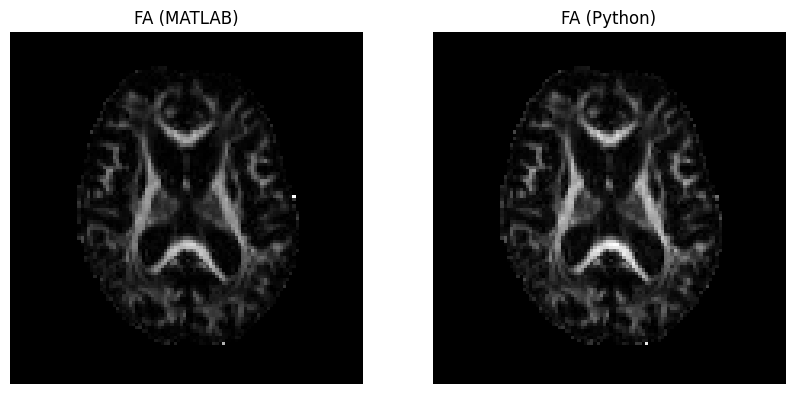

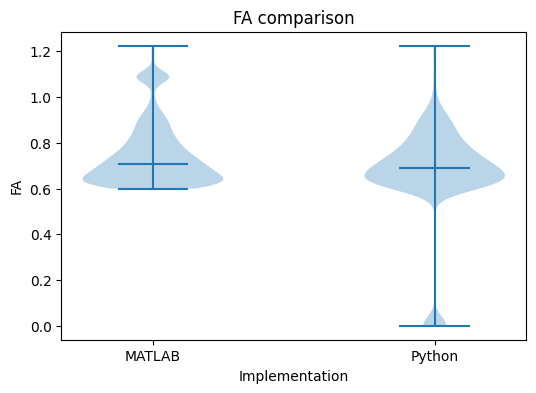

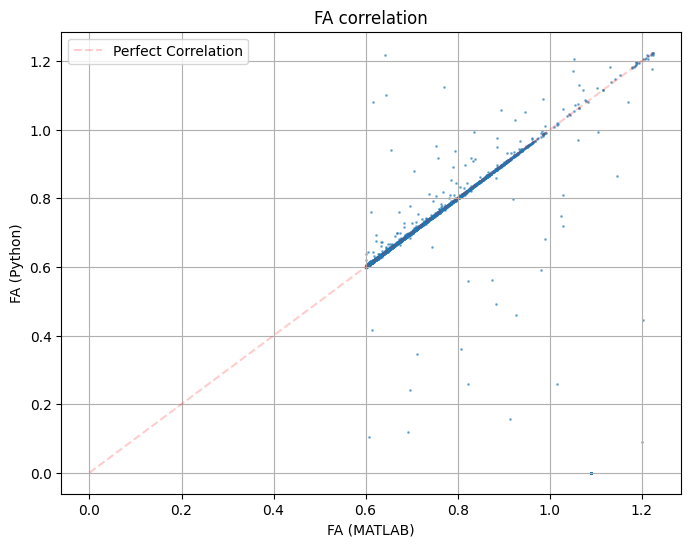

In [201]:
plot_violin_scatter("C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/data_reference/_FA.nii.gz",
                    "C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/output_python_v1/FA_final.nii.gz",
                    "FA",mask_matlab)

In [203]:
dictionary_mean_abs_error = {}

0.07850572


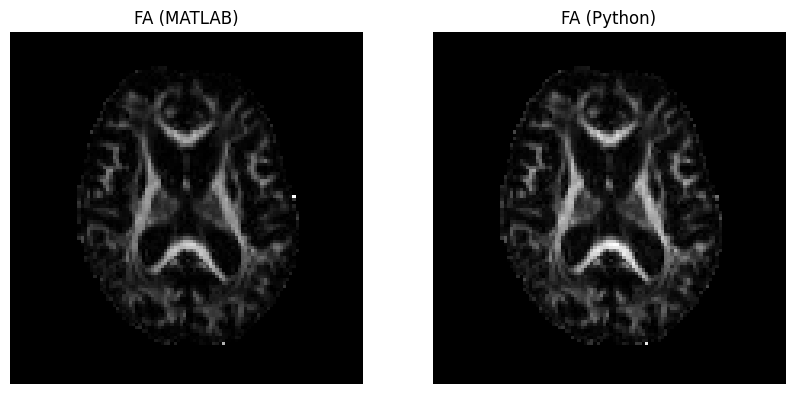

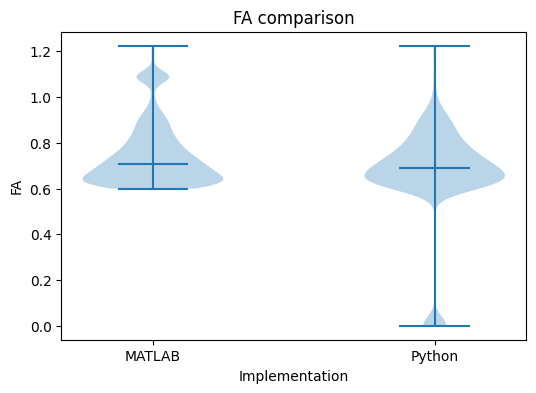

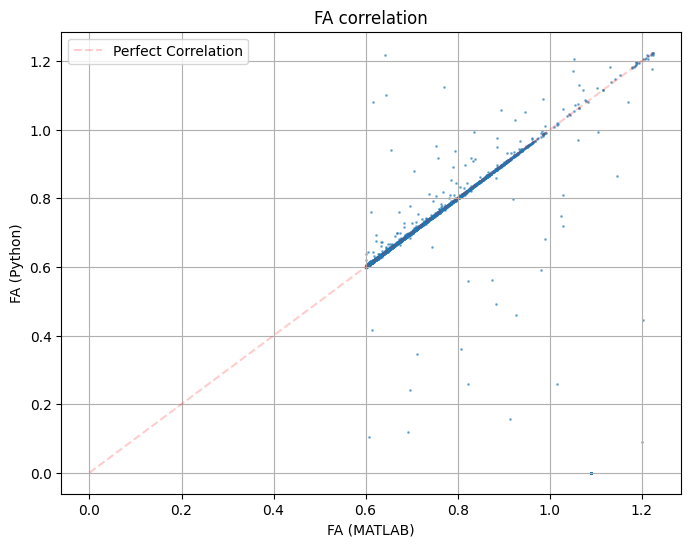

In [204]:
metric = "FA"
dictionary_mean_abs_error[metric] = plot_violin_scatter("C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/data_reference/_"+metric+".nii.gz",
                    "C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/output_python_v1/"+metric+"_final.nii.gz",
                    metric,mask_matlab)

0.0014599717


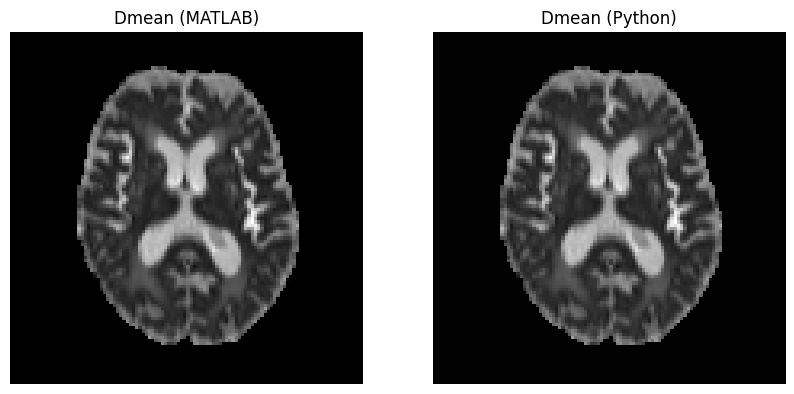

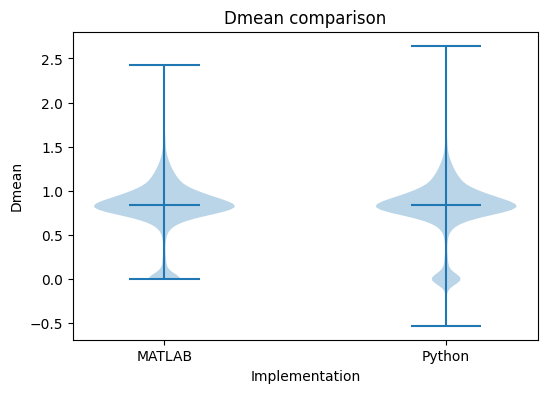

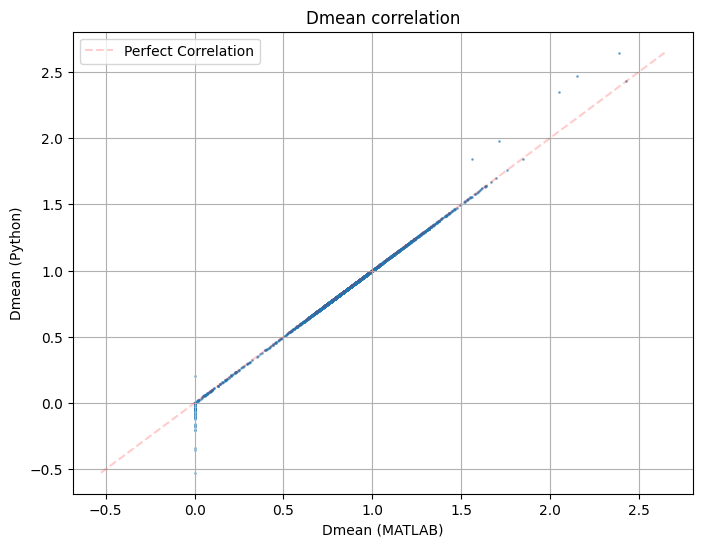

In [207]:
metric = "Dmean"
dictionary_mean_abs_error[metric] = plot_violin_scatter("C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/data_reference/_"+metric+".nii.gz",
                    "C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/output_python_v1/"+metric+"_final.nii.gz",
                    metric,mask_matlab)

0.007824535


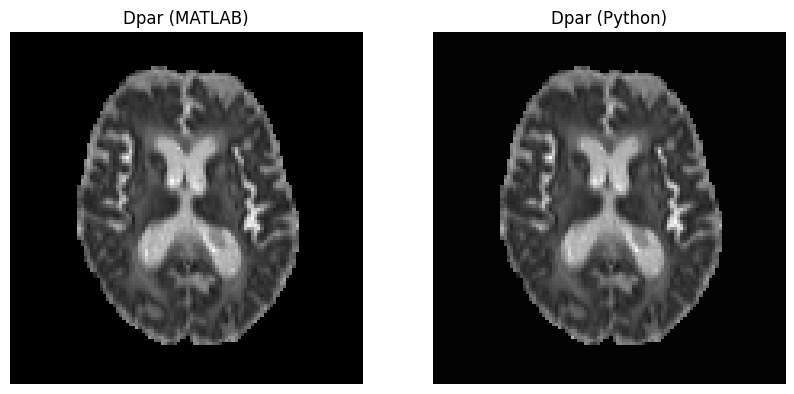

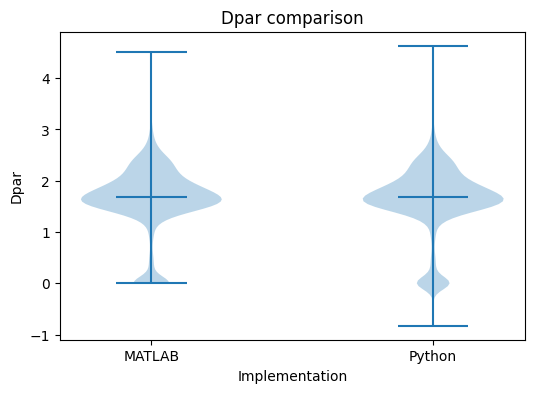

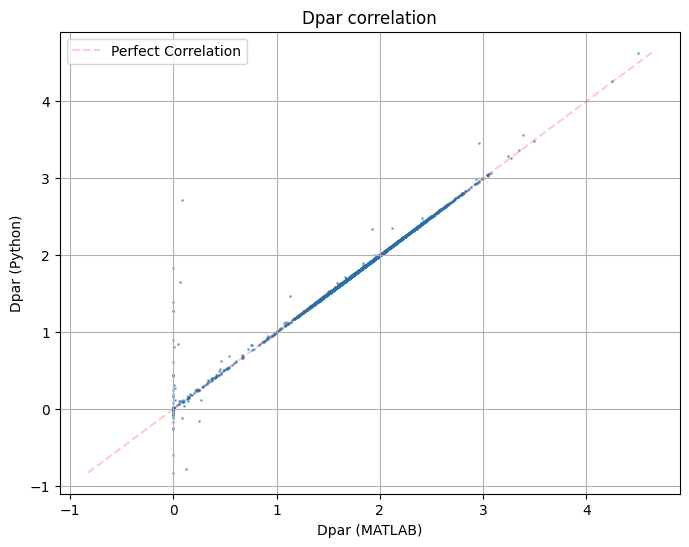

In [208]:
metric = "Dpar"
dictionary_mean_abs_error[metric] = plot_violin_scatter("C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/data_reference/_"+metric+".nii.gz",
                    "C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/output_python_v1/"+metric+"_final.nii.gz",
                    metric,mask_matlab)

0.006324549


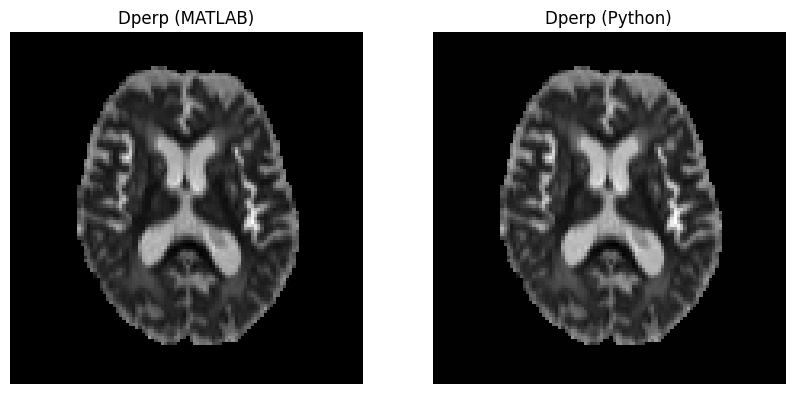

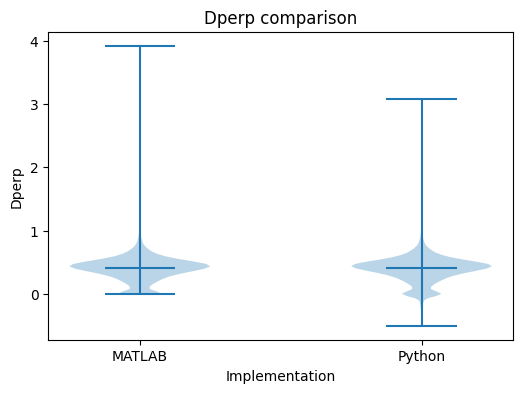

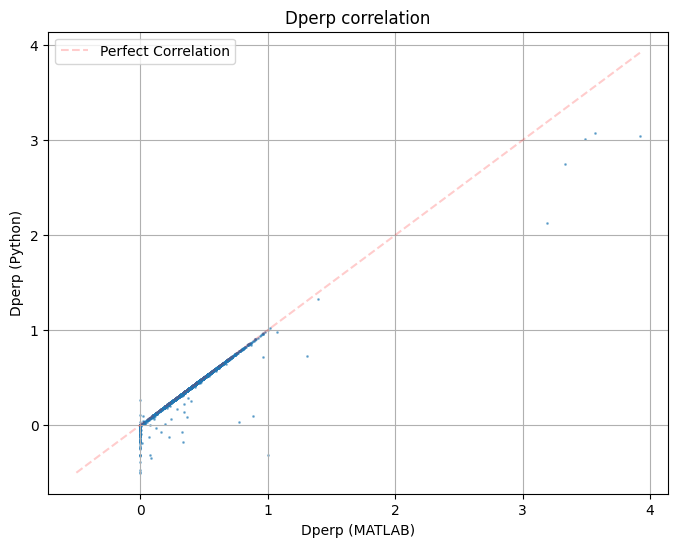

In [209]:
metric = "Dperp"
dictionary_mean_abs_error[metric] = plot_violin_scatter("C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/data_reference/_"+metric+".nii.gz",
                    "C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/output_python_v1/"+metric+"_final.nii.gz",
                    metric,mask_matlab)

0.0005222767


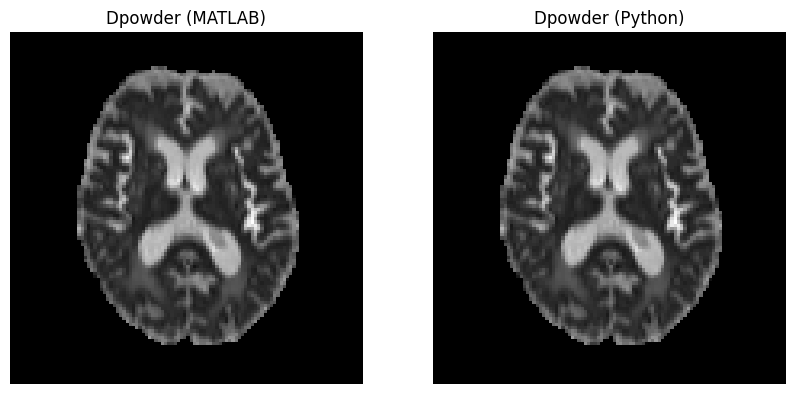

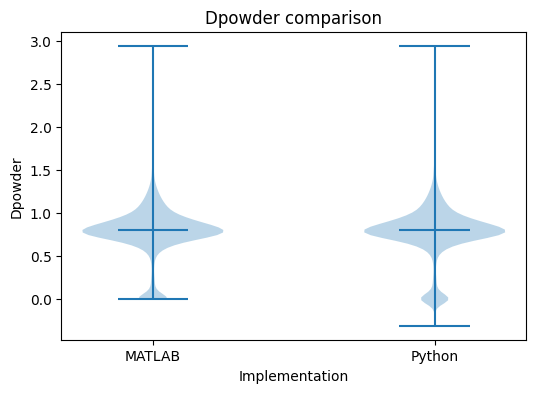

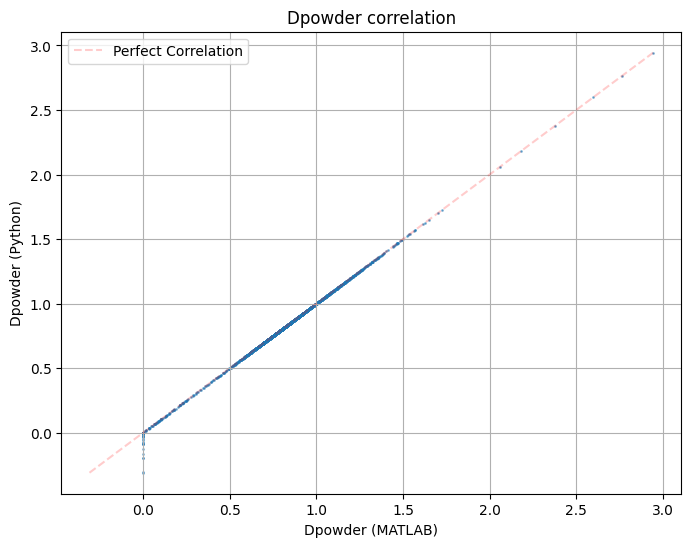

In [210]:
metric = "Dpowder"
dictionary_mean_abs_error[metric] = plot_violin_scatter("C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/data_reference/_"+metric+".nii.gz",
                    "C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/output_python_v1/"+metric+"_final.nii.gz",
                    metric,mask_matlab)

0.04249914


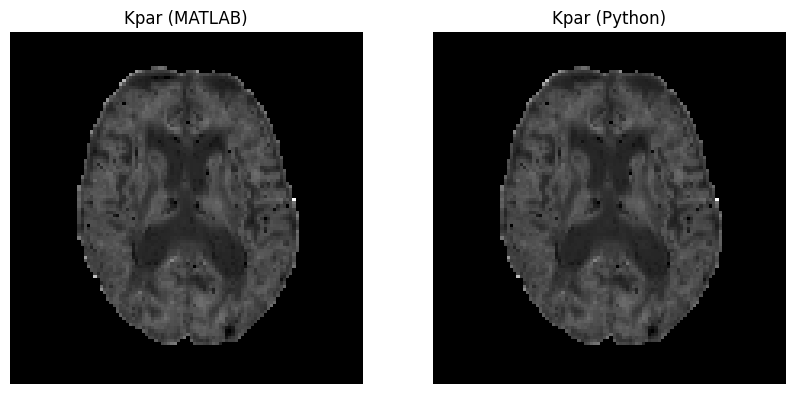

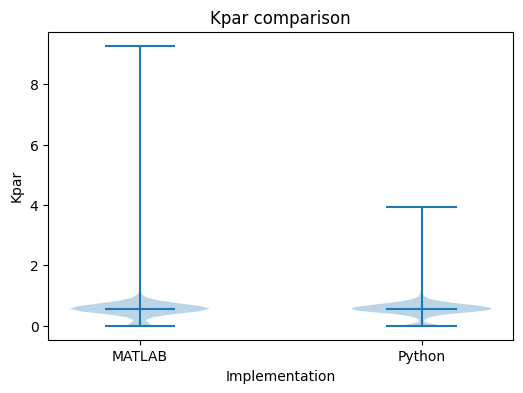

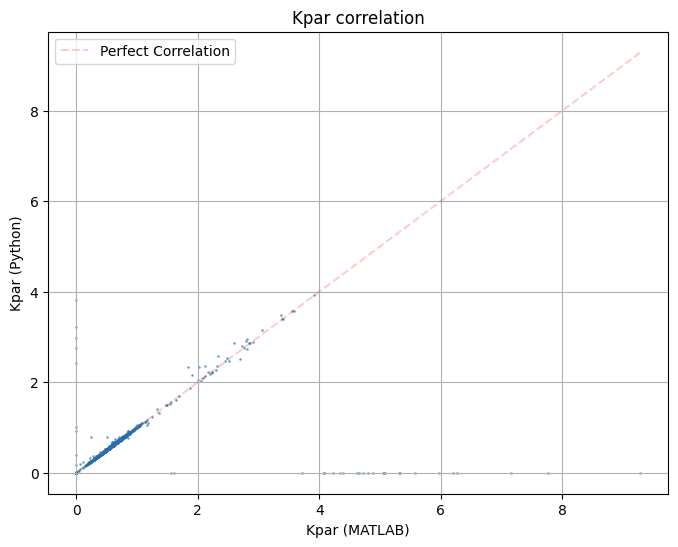

In [244]:
metric = "Kpar"
dictionary_mean_abs_error[metric] = plot_violin_scatter("C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/data_reference/_"+metric+".nii.gz",
                    "C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/output_python_v1/"+metric+"_final.nii.gz",
                    metric,mask_matlab)

0.07786149


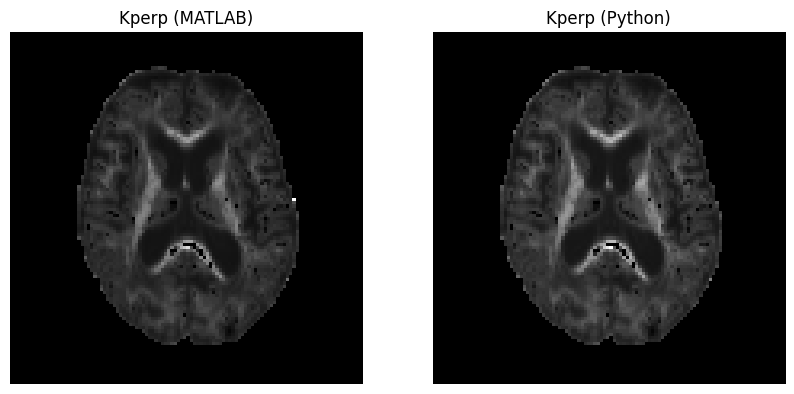

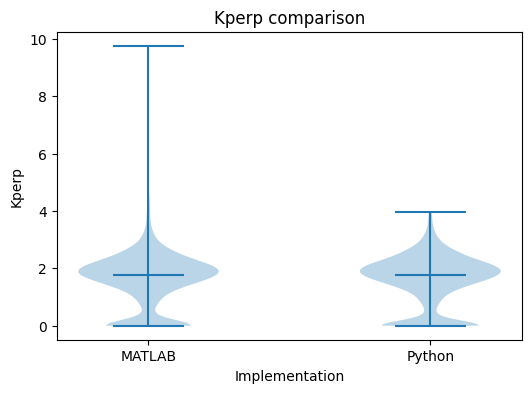

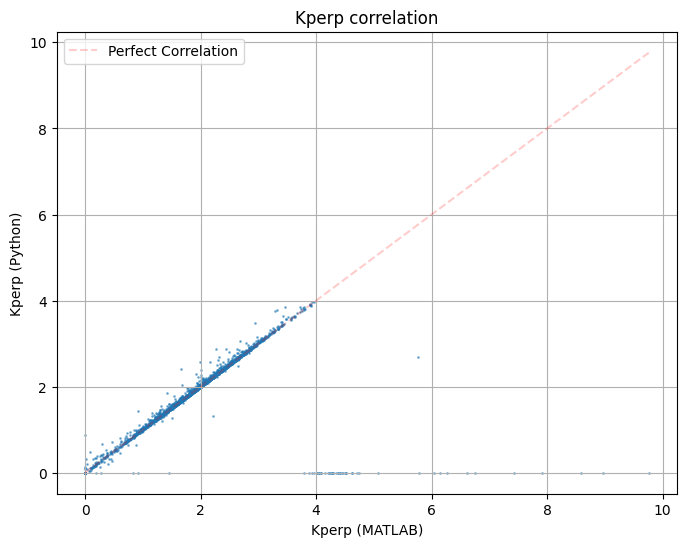

In [245]:
metric = "Kperp"
dictionary_mean_abs_error[metric] = plot_violin_scatter("C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/data_reference/_"+metric+".nii.gz",
                    "C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/output_python_v1/"+metric+"_final.nii.gz",
                    metric,mask_matlab)

0.02522207


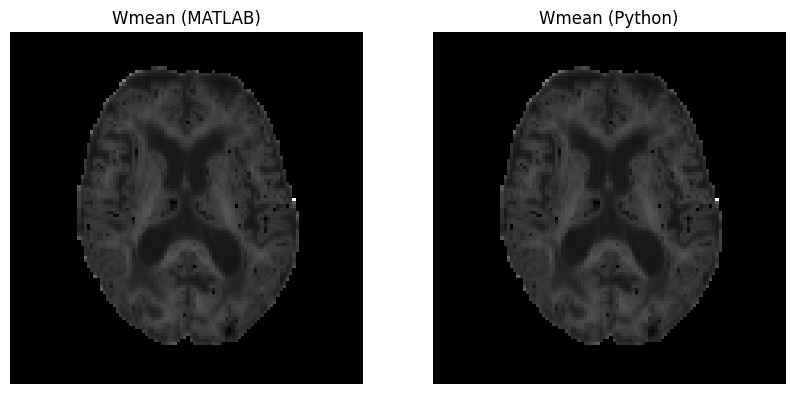

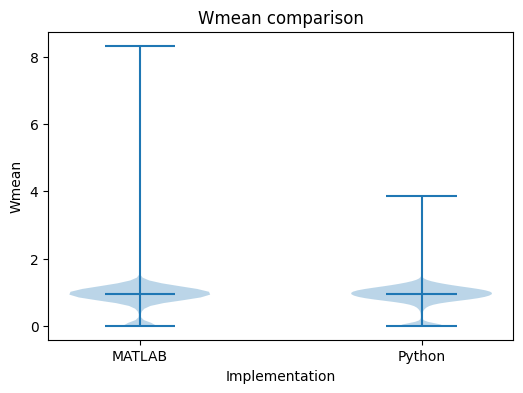

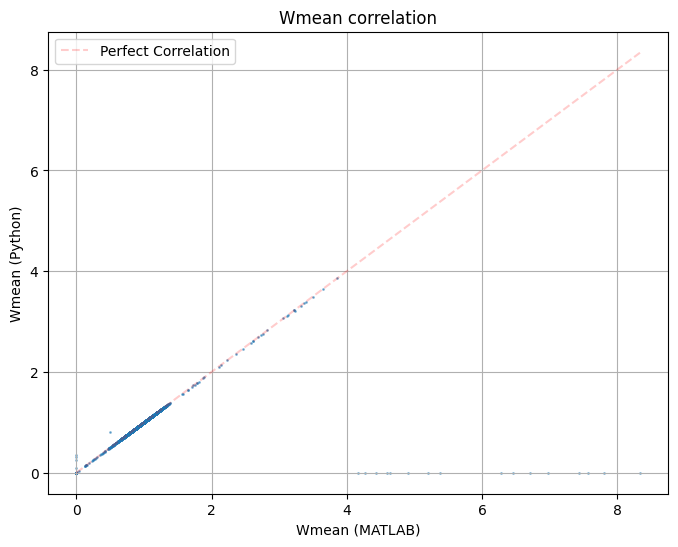

In [246]:
metric = "Wmean"
dictionary_mean_abs_error[metric] = plot_violin_scatter("C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/data_reference/_"+metric+".nii.gz",
                    "C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/output_python_v1/"+metric+"_final.nii.gz",
                    metric,mask_matlab)

0.031100536


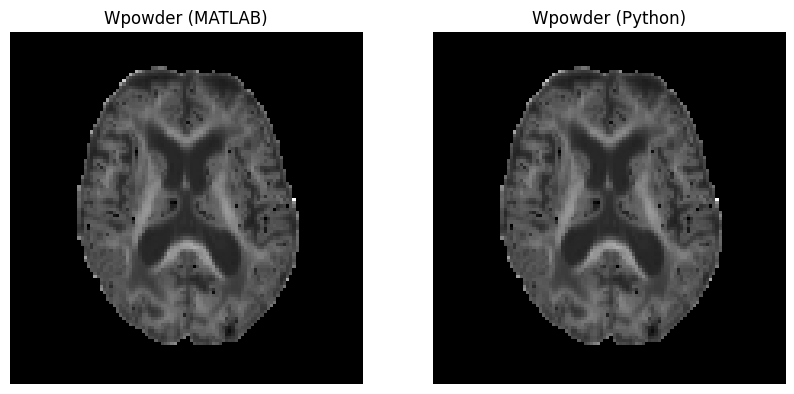

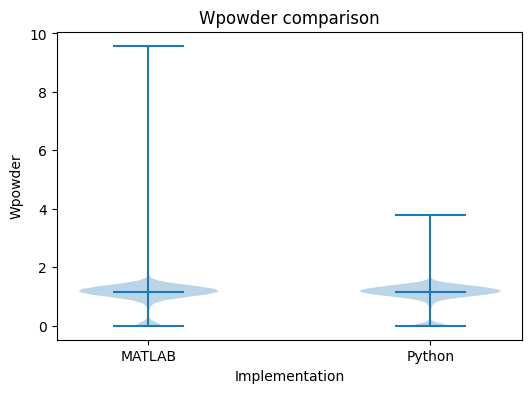

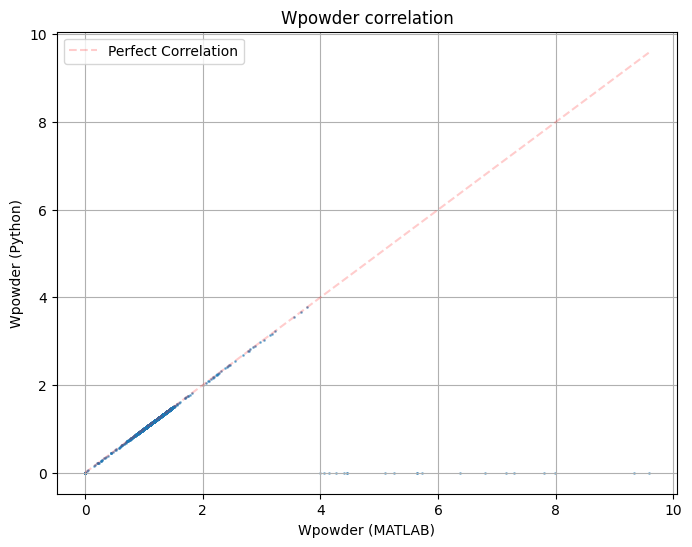

In [247]:
metric = "Wpowder"
dictionary_mean_abs_error[metric] = plot_violin_scatter("C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/data_reference/_"+metric+".nii.gz",
                    "C:/Users/vissa/OneDrive/Documentos/2025-DELlatitude3540/PostDoc_Canada/conferences/Brainhack_Western/axdki/output_python_v1/"+metric+"_final.nii.gz",
                    metric,mask_matlab)

In [248]:
dictionary_mean_abs_error

{'FA': np.float32(0.07850572),
 'Dmean': np.float32(0.0014599717),
 'Dpar': np.float32(0.007824535),
 'Dperp': np.float32(0.006324549),
 'Dpowder': np.float32(0.0005222767),
 'Kpar': np.float32(0.04249914),
 'Kperp': np.float32(0.07786149),
 'Wmean': np.float32(0.02522207),
 'Wpowder': np.float32(0.031100536)}